In [ ]:
from google.colab import drive
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# Google drive mount (it is only needed once, but it is better to include it)
drive.mount('/content/drive')
print("Google Drive connected sucessfully. Everything is ready for a Patient-level split.")

Mounted at /content/drive
Google Drive connected sucessfully. Everything is ready for a Patient-level split.


In [ ]:
!cp -r "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification" "/content/dataset_original_local"

Preprocessing

In [ ]:
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# Dictionary mapping the original classes to the Binary categories (Stage 1)
BINARY_MAPPING = {
    'adenosis': 'Benign',
    'fibroadenoma': 'Benign',
    'phyllodes_tumor': 'Benign',
    'tubular_adenoma': 'Benign',
    'ductal_carcinoma': 'Malignant',
    'lobular_carcinoma': 'Malignant',
    'mucinous_carcinoma': 'Malignant',
    'papillary_carcinoma': 'Malignant'
}

def get_patient_id(filename):
    """
    Extracts a unique patient ID from the filename.
    """
    parts = filename.split('-')
    if len(parts) >= 3:
        return f"{parts[1]}-{parts[2]}"
    return filename

def process_dataset_binary_split(origin_path, final_path='/content/data_split_binary', train_size=0.8, seed=42):
    random.seed(seed)
    origin = Path(origin_path)
    final_p = Path(final_path)

    if final_p.exists():
        print(f"Erasing old directory '{final_p}'...")
        shutil.rmtree(final_p)

    zooms = [f.name for f in origin.iterdir() if f.is_dir()]
    print(f"Detected zooms: {zooms}\n")

    extensions = ('*.png', '*.jpg', '*.jpeg', '*.tiff', '*.bmp')
    total_train, total_test = 0, 0

    for amp in zooms:
        classes = [d.name for d in (origin / amp).iterdir() if d.is_dir()]
        patients_dict = {c: {} for c in classes}

        # Group images by patient ID for each original class
        for c in classes:
            for ext in extensions:
                for img in (origin / amp / c).glob(ext):
                    p_id = get_patient_id(img.name)
                    if p_id not in patients_dict[c]:
                        patients_dict[c][p_id] = []
                    patients_dict[c][p_id].append(img)

        amp_train_count, amp_test_count = 0, 0

        for c in classes:
            all_patients = list(patients_dict[c].keys())

            if len(all_patients) == 1:
                train_p, test_p = all_patients, []
            else:
                train_p, test_p = train_test_split(all_patients, train_size=train_size, random_state=seed)

            # CORE LOGIC: Map the original class to the Binary superclass
            super_class = BINARY_MAPPING.get(c, c)
            train_dest = final_p / 'train' / super_class
            test_dest = final_p / 'test' / super_class
            train_dest.mkdir(parents=True, exist_ok=True)
            test_dest.mkdir(parents=True, exist_ok=True)

            for p_id in train_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, train_dest / f"{amp}_{img.name}")
                    amp_train_count += 1

            for p_id in test_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, test_dest / f"{amp}_{img.name}")
                    amp_test_count += 1

        print(f" Zoom {amp} processed (Binary Split):")
        print(f"   - Images added to TRAIN: {amp_train_count}")
        print(f"   - Images added to TEST : {amp_test_count}\n")

        total_train += amp_train_count
        total_test += amp_test_count

    print("-" * 50)
    print("The Binary patient-level split has finished successfully.")
    print(f"New clean data stored in: '{final_path}/'")
    print(f"Total images in TRAIN: {total_train}")
    print(f"Total images in TEST: {total_test}")

# Execution using the local dataset directory
source_path = '/content/dataset_original_local'
local_dest_path = '/content/data_split_binary'

process_dataset_binary_split(origin_path=source_path, final_path=local_dest_path)

Detected zooms: ['100X', '400X', '200X', '40X']

 Zoom 100X processed (Binary Split):
   - Images added to TRAIN: 1598
   - Images added to TEST : 483

 Zoom 400X processed (Binary Split):
   - Images added to TRAIN: 1413
   - Images added to TEST : 407

 Zoom 200X processed (Binary Split):
   - Images added to TRAIN: 1526
   - Images added to TEST : 487

 Zoom 40X processed (Binary Split):
   - Images added to TRAIN: 1478
   - Images added to TEST : 517

--------------------------------------------------
The Binary patient-level split has finished successfully.
New clean data stored in: '/content/data_split_binary/'
Total images in TRAIN: 6015
Total images in TEST: 1894


Focal loss and balanced dataloaders

In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler

# ==========================================
# FOCAL LOSS IMPLEMENTATION
# ==========================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss for binary/multi-class classification.
        """
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.alpha = alpha

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# ==========================================
# DATALOADERS & BALANCING
# ==========================================
# Data Augmentation transforms for the training set
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Test dataset remains without augmentations
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset_binary = datasets.ImageFolder(root='/content/data_split_binary/train', transform=transform_train_da)
test_dataset_binary = datasets.ImageFolder(root='/content/data_split_binary/test', transform=transform_test)

# --- CONFIGURATION TO EQUALIZE BINARY CLASSES ---
class_counts = np.bincount(train_dataset_binary.targets)
max_class_count = max(class_counts)

class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[t] for t in train_dataset_binary.targets])
sample_weights = torch.from_numpy(sample_weights).double()

# Force int conversion to avoid PyTorch ValueError
balanced_num_samples = int(max_class_count * len(train_dataset_binary.classes))

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=balanced_num_samples, replacement=True)

# IMPORTANT: shuffle MUST be False when using a sampler
train_loader_binary = DataLoader(train_dataset_binary, batch_size=32, sampler=sampler, num_workers=0, pin_memory=False)
test_loader_binary = DataLoader(test_dataset_binary, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print(f"Total original Train images: {len(train_dataset_binary)}")
print(f"Effective Train images per epoch (after DA balancing): {balanced_num_samples}")
print(f"Detected Stage 1 Classes: {train_dataset_binary.class_to_idx}")

Total original Train images: 6015
Effective Train images per epoch (after DA balancing): 8458
Detected Stage 1 Classes: {'Benign': 0, 'Malignant': 1}


ViT Initialization for Binary Classification (Stage 1)

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# ==========================================
# ViT MODEL INITIALIZATION (BINARY)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Load pre-trained Vision Transformer (ViT Base 16)
model_vit_binary = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

# Ensure all layers are unfrozen for full fine-tuning
for param in model_vit_binary.parameters():
    param.requires_grad = True

# Modify the final classification head for binary classification (2 classes)
num_ftrs = model_vit_binary.heads.head.in_features
num_classes_binary = len(train_dataset_binary.classes) # Automatically detects 2 classes

# Replace the last layer
model_vit_binary.heads.head = nn.Linear(num_ftrs, num_classes_binary)
model_vit_binary = model_vit_binary.to(device)

# Initialize Focal Loss with gamma=2.0 to penalize hard-to-classify examples
criterion_binary = FocalLoss(gamma=2.0)
optimizer_binary = optim.Adam(model_vit_binary.parameters(), lr=0.0001)

print(f"ViT architecture ready for {num_classes_binary}-class (Binary) classification.")

Training on device: cuda
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 138MB/s]


ViT architecture ready for 2-class (Binary) classification.


Training Loop and Saving Phase (Stage 1)

Starting training for Stage 1 (Binary: Benign vs Malignant) with Focal Loss...

Epoch 1/15 (369.0s) -> Train Loss: 0.1314 | Train Acc: 0.7913 || Test Loss: 0.1121 | Test Acc: 0.7930
Epoch 2/15 (390.1s) -> Train Loss: 0.0583 | Train Acc: 0.9131 || Test Loss: 0.1098 | Test Acc: 0.8316
Epoch 3/15 (372.5s) -> Train Loss: 0.0361 | Train Acc: 0.9498 || Test Loss: 0.1760 | Test Acc: 0.8273
Epoch 4/15 (369.4s) -> Train Loss: 0.0238 | Train Acc: 0.9684 || Test Loss: 0.0969 | Test Acc: 0.8654
Epoch 5/15 (370.3s) -> Train Loss: 0.0198 | Train Acc: 0.9743 || Test Loss: 0.1096 | Test Acc: 0.8733
Epoch 6/15 (369.6s) -> Train Loss: 0.0186 | Train Acc: 0.9768 || Test Loss: 0.1030 | Test Acc: 0.9018
Epoch 7/15 (370.0s) -> Train Loss: 0.0150 | Train Acc: 0.9805 || Test Loss: 0.1185 | Test Acc: 0.8601
Epoch 8/15 (369.3s) -> Train Loss: 0.0146 | Train Acc: 0.9818 || Test Loss: 0.1165 | Test Acc: 0.8759
Epoch 9/15 (369.6s) -> Train Loss: 0.0098 | Train Acc: 0.9870 || Test Loss: 0.2210 | Test Acc: 0.8353
Ep

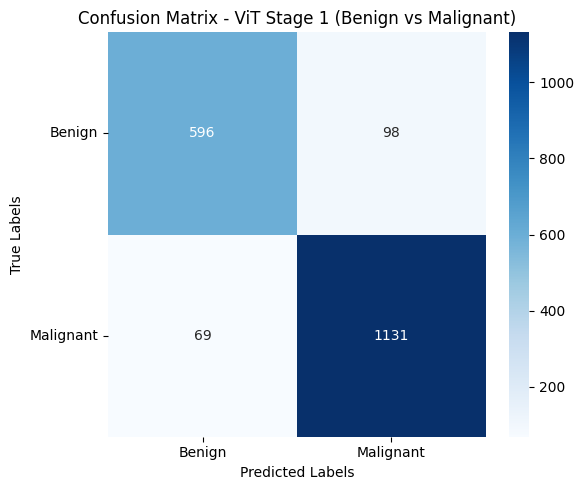

Model saved as 'vit_FocalLoss_Stage1_Binary.pth'


In [ ]:
import time
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# TRAINING LOOP (STAGE 1: BINARY)
# ==========================================
NUM_EPOCHS = 15
print("Starting training for Stage 1 (Binary: Benign vs Malignant) with Focal Loss...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model_vit_binary.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader_binary:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer_binary.zero_grad()
        outputs = model_vit_binary(inputs)
        loss = criterion_binary(outputs, labels)

        loss.backward()
        optimizer_binary.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # --- VALIDATION (TEST) PHASE ---
    model_vit_binary.eval()
    running_test_loss, running_test_corrects, total_test = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader_binary:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model_vit_binary(inputs)
            loss = criterion_binary(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

            # Store predictions for the final epoch matrix
            if epoch == NUM_EPOCHS - 1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nStage 1 Training finished successfully.")

# ==========================================
# EVALUATION & CONFUSION MATRIX
# ==========================================
print("\nGenerating Detailed Performance Report for Binary Classification...")
class_names_binary = [train_dataset_binary.classes[i] for i in range(num_classes_binary)]

report = classification_report(all_labels, all_preds, target_names=class_names_binary, zero_division=0)
print("-" * 50)
print(report)
print("-" * 50)

# Generate and plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_binary, yticklabels=class_names_binary)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ViT Stage 1 (Benign vs Malignant)')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save the binary classifier model
save_path_binary = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/vit_FocalLoss_Stage1_Binary.pth"
torch.save(model_vit_binary.state_dict(), save_path_binary)
print(f"Model saved as 'vit_FocalLoss_Stage1_Binary.pth'")

The matrix has to have a rotation to apply to the previous experiments

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Identify the internal indices (assuming 0 was Benign and 1 was Malignant)
# We force Malignant to be first (index 1) and Benign to be second (index 0)
clinical_labels_order = [1, 0]
custom_class_names = ['Malignant (Positive)', 'Benign (Negative)']

# 2. Generate the confusion matrix with the forced clinical order
cm_clinical = confusion_matrix(all_labels, all_preds, labels=clinical_labels_order)

# 3. Plot the heatmap
plt.figure(figsize=(7, 6))
sns.heatmap(cm_clinical, annot=True, fmt='d', cmap='Blues',
            xticklabels=custom_class_names,
            yticklabels=custom_class_names)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Clinical Confusion Matrix - ViT Stage 1')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
# plt.savefig('clinical_confusion_matrix_stage1.png', dpi=300) # Uncomment to save
plt.show()

Graphical representation of the data

In [ ]:
import matplotlib.pyplot as plt

# 1. Data extracted from the training logs (Stage 1 Binary: Benign vs Malignant)
epochs = list(range(1, 16))

train_loss = [0.1314, 0.0583, 0.0361, 0.0238, 0.0198, 0.0186, 0.0150, 0.0146, 0.0098, 0.0118, 0.0118, 0.0095, 0.0108, 0.0083, 0.0058]
test_loss = [0.1121, 0.1098, 0.1760, 0.0969, 0.1096, 0.1030, 0.1185, 0.1165, 0.2210, 0.1267, 0.1223, 0.1588, 0.1286, 0.1049, 0.1241]

train_acc = [0.7913, 0.9131, 0.9498, 0.9684, 0.9743, 0.9768, 0.9805, 0.9818, 0.9870, 0.9857, 0.9840, 0.9870, 0.9865, 0.9895, 0.9924]
test_acc = [0.7930, 0.8316, 0.8273, 0.8654, 0.8733, 0.9018, 0.8601, 0.8759, 0.8353, 0.8928, 0.8559, 0.8527, 0.8627, 0.8902, 0.9118]

# 2. Figure setup (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ViT Stage 1 (Binary: Benign vs Malignant) WITH Focal Loss & DA', fontsize=16)

# 3. Loss Evolution Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', color='#d62728', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (Focal)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 4. Accuracy Evolution Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', color='#1f77b4', linewidth=2)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', color='#d62728', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# 5. Display and optionally save the figure
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('vit_stage1_binary_metrics.png', dpi=300) # Uncomment to save
plt.show()

Dataset Filtration and Split for Subtypes (Stage 2)

In [ ]:
import os
import shutil
import random
from pathlib import Path
from sklearn.model_selection import train_test_split

# Define the exact classes that belong to each sub-model
BENIGN_CLASSES = ['adenosis', 'fibroadenoma', 'phyllodes_tumor', 'tubular_adenoma']
MALIGNANT_CLASSES = ['ductal_carcinoma', 'lobular_carcinoma', 'mucinous_carcinoma', 'papillary_carcinoma']

def get_patient_id(filename):
    """Extracts a unique patient ID from the filename."""
    parts = filename.split('-')
    if len(parts) >= 3:
        return f"{parts[1]}-{parts[2]}"
    return filename

def process_stage2_split(origin_path, target_classes, final_path, train_size=0.8, seed=42):
    """
    Filters the dataset for specific target classes and splits it by patient.
    """
    random.seed(seed)
    origin = Path(origin_path)
    final_p = Path(final_path)

    if final_p.exists():
        print(f"Erasing old directory '{final_p}'...")
        shutil.rmtree(final_p)

    zooms = [f.name for f in origin.iterdir() if f.is_dir()]
    extensions = ('*.png', '*.jpg', '*.jpeg', '*.tiff', '*.bmp')
    total_train, total_test = 0, 0

    for amp in zooms:
        # ONLY select classes that belong to the specified target list (Benign or Malignant)
        classes = [d.name for d in (origin / amp).iterdir() if d.is_dir() and d.name in target_classes]
        patients_dict = {c: {} for c in classes}

        for c in classes:
            for ext in extensions:
                for img in (origin / amp / c).glob(ext):
                    p_id = get_patient_id(img.name)
                    if p_id not in patients_dict[c]:
                        patients_dict[c][p_id] = []
                    patients_dict[c][p_id].append(img)

        amp_train_count, amp_test_count = 0, 0

        for c in classes:
            all_patients = list(patients_dict[c].keys())

            if len(all_patients) == 1:
                train_p, test_p = all_patients, []
            else:
                train_p, test_p = train_test_split(all_patients, train_size=train_size, random_state=seed)

            # Keep the original class names, but isolated in the new target directory
            train_dest = final_p / 'train' / c
            test_dest = final_p / 'test' / c
            train_dest.mkdir(parents=True, exist_ok=True)
            test_dest.mkdir(parents=True, exist_ok=True)

            for p_id in train_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, train_dest / f"{amp}_{img.name}")
                    amp_train_count += 1

            for p_id in test_p:
                for img in patients_dict[c][p_id]:
                    shutil.copy(img, test_dest / f"{amp}_{img.name}")
                    amp_test_count += 1

        total_train += amp_train_count
        total_test += amp_test_count

    print(f"Split finished for {final_path}")
    print(f"Total images in TRAIN: {total_train} | TEST: {total_test}\n")

# Execution: Create two isolated datasets
source_path = '/content/dataset_original_local'
dest_path_benign = '/content/data_split_stage2_benign'
dest_path_malignant = '/content/data_split_stage2_malignant'

print("--- Generating Stage 2A (Benign Subtypes) Dataset ---")
process_stage2_split(source_path, BENIGN_CLASSES, dest_path_benign)

print("--- Generating Stage 2B (Malignant Subtypes) Dataset ---")
process_stage2_split(source_path, MALIGNANT_CLASSES, dest_path_malignant)

--- Generating Stage 2A (Benign Subtypes) Dataset ---
Split finished for /content/data_split_stage2_benign
Total images in TRAIN: 1786 | TEST: 694

--- Generating Stage 2B (Malignant Subtypes) Dataset ---
Split finished for /content/data_split_stage2_malignant
Total images in TRAIN: 4229 | TEST: 1200



Dataloaders, Balancing, and Model Init (Stage 2: Benign Example)

In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler

# ==========================================
# DATALOADERS & BALANCING (BENIGN DATASET)
# ==========================================
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Point to the Benign folder
train_dataset_ben = datasets.ImageFolder(root='/content/data_split_stage2_benign/train', transform=transform_train_da)
test_dataset_ben = datasets.ImageFolder(root='/content/data_split_stage2_benign/test', transform=transform_test)

# --- EQUALIZE CLASSES (Oversampling minority benign subclasses) ---
class_counts = np.bincount(train_dataset_ben.targets)
max_class_count = max(class_counts)

class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[t] for t in train_dataset_ben.targets])
sample_weights = torch.from_numpy(sample_weights).double()

balanced_num_samples = int(max_class_count * len(train_dataset_ben.classes))

sampler_ben = WeightedRandomSampler(weights=sample_weights, num_samples=balanced_num_samples, replacement=True)

train_loader_ben = DataLoader(train_dataset_ben, batch_size=32, sampler=sampler_ben, num_workers=0, pin_memory=False)
test_loader_ben = DataLoader(test_dataset_ben, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print(f"Detected Stage 2A Benign Classes: {train_dataset_ben.class_to_idx}")

# ==========================================
# ViT MODEL INITIALIZATION (STAGE 2A)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_vit_ben = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

for param in model_vit_ben.parameters():
    param.requires_grad = True

# Detects the specific benign classes
num_ftrs = model_vit_ben.heads.head.in_features
num_classes_ben = len(train_dataset_ben.classes)

model_vit_ben.heads.head = nn.Linear(num_ftrs, num_classes_ben)
model_vit_ben = model_vit_ben.to(device)

# Using the previously defined Focal Loss class
criterion_ben = FocalLoss(gamma=2.0)
optimizer_ben = optim.Adam(model_vit_ben.parameters(), lr=0.0001)

print(f"ViT architecture ready for Benign Subtype classification ({num_classes_ben} classes).")

Detected Stage 2A Benign Classes: {'adenosis': 0, 'fibroadenoma': 1, 'phyllodes_tumor': 2, 'tubular_adenoma': 3}
ViT architecture ready for Benign Subtype classification (4 classes).


Training Loop and Evaluation (Stage 2: Benign Subtypes)

Starting training for Stage 2A (Benign Subtypes) with Focal Loss...

Epoch 1/15 (143.0s) -> Train Loss: 0.3823 | Train Acc: 0.6595 || Test Loss: 0.4652 | Test Acc: 0.6455
Epoch 2/15 (143.3s) -> Train Loss: 0.1152 | Train Acc: 0.8755 || Test Loss: 0.3536 | Test Acc: 0.7334
Epoch 3/15 (143.2s) -> Train Loss: 0.0573 | Train Acc: 0.9380 || Test Loss: 0.3778 | Test Acc: 0.7176
Epoch 4/15 (143.5s) -> Train Loss: 0.0326 | Train Acc: 0.9663 || Test Loss: 0.7298 | Test Acc: 0.6527
Epoch 5/15 (143.5s) -> Train Loss: 0.0373 | Train Acc: 0.9605 || Test Loss: 0.6026 | Test Acc: 0.6830
Epoch 6/15 (143.3s) -> Train Loss: 0.0158 | Train Acc: 0.9824 || Test Loss: 0.5562 | Test Acc: 0.7075
Epoch 7/15 (143.2s) -> Train Loss: 0.0085 | Train Acc: 0.9900 || Test Loss: 1.0912 | Test Acc: 0.6787
Epoch 8/15 (143.4s) -> Train Loss: 0.0214 | Train Acc: 0.9784 || Test Loss: 0.9583 | Test Acc: 0.6758
Epoch 9/15 (143.5s) -> Train Loss: 0.0335 | Train Acc: 0.9681 || Test Loss: 0.6810 | Test Acc: 0.6801
Epoch 10/15 (

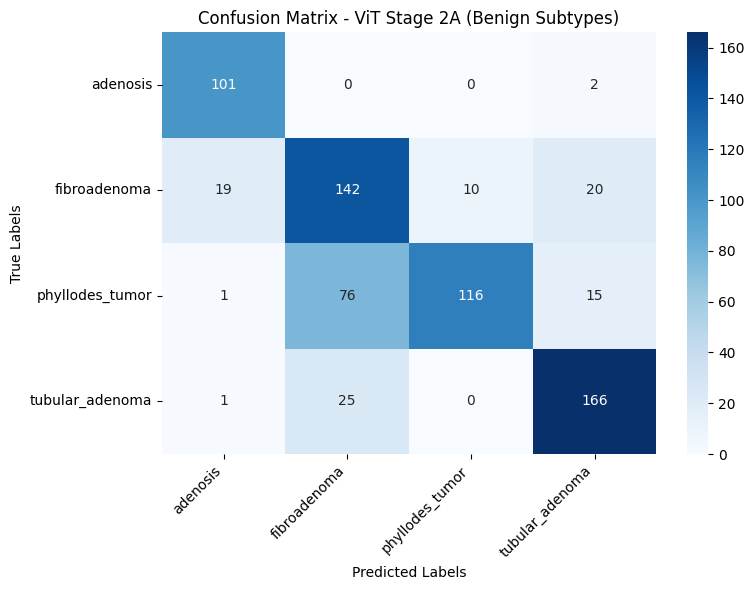

Model saved as 'vit_FocalLoss_Stage2A_Benign.pth'


In [ ]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# TRAINING LOOP (STAGE 2A: BENIGN SUBTYPES)
# ==========================================
NUM_EPOCHS = 15
print("Starting training for Stage 2A (Benign Subtypes) with Focal Loss...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model_vit_ben.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader_ben:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer_ben.zero_grad()
        outputs = model_vit_ben(inputs)

        loss = criterion_ben(outputs, labels)

        loss.backward()
        optimizer_ben.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # --- VALIDATION (TEST) PHASE ---
    model_vit_ben.eval()
    running_test_loss, running_test_corrects, total_test = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader_ben:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            outputs = model_vit_ben(inputs)
            loss = criterion_ben(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

            # Store predictions during the final epoch to generate the confusion matrix
            if epoch == NUM_EPOCHS - 1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nStage 2A (Benign Subtypes) Training finished successfully.")

# ==========================================
# EVALUATION & CONFUSION MATRIX
# ==========================================
print("\nGenerating Detailed Performance Report for Benign Subtypes...")
class_names_ben = [train_dataset_ben.classes[i] for i in range(num_classes_ben)]

# Generate the classification report
report_ben = classification_report(all_labels, all_preds, target_names=class_names_ben, zero_division=0)
print("-" * 50)
print(report_ben)
print("-" * 50)

# Generate and plot confusion matrix
cm_ben = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ben, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_ben, yticklabels=class_names_ben)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ViT Stage 2A (Benign Subtypes)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save the Benign subtype classifier model
save_path_ben = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/vit_FocalLoss_Stage2A_Benign.pth"
torch.save(model_vit_ben.state_dict(), save_path_ben)
print(f"Model saved as 'vit_FocalLoss_Stage2A_Benign.pth'")

Graphical representation of the data

In [ ]:
import matplotlib.pyplot as plt

# 1. Data extracted from the training logs (Stage 2 Subtypes)
epochs = list(range(1, 16))

train_loss = [0.3823, 0.1152, 0.0573, 0.0326, 0.0373, 0.0158, 0.0085, 0.0214, 0.0335, 0.0178, 0.0158, 0.0128, 0.0339, 0.0102, 0.0097]
test_loss = [0.4652, 0.3536, 0.3778, 0.7298, 0.6026, 0.5562, 1.0912, 0.9583, 0.6810, 0.7391, 0.8239, 0.7468, 0.6255, 0.7726, 0.3729]

train_acc = [0.6595, 0.8755, 0.9380, 0.9663, 0.9605, 0.9824, 0.9900, 0.9784, 0.9681, 0.9818, 0.9815, 0.9866, 0.9660, 0.9882, 0.9885]
test_acc = [0.6455, 0.7334, 0.7176, 0.6527, 0.6830, 0.7075, 0.6787, 0.6758, 0.6801, 0.7233, 0.7147, 0.6787, 0.7190, 0.6888, 0.7565]

# 2. Figure setup (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('ViT Stage 2 (Subtype Classification) WITH Focal Loss & DA', fontsize=16)

# 3. Loss Evolution Plot
ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', color='#1f77b4', linewidth=2)
ax1.plot(epochs, test_loss, 'r--o', label='Test Loss', color='#d62728', linewidth=2)
ax1.set_title('Loss Evolution')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss (Focal)')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# 4. Accuracy Evolution Plot
ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy', color='#2ca02c', linewidth=2)
ax2.plot(epochs, test_acc, 'r--o', label='Test Accuracy', color='#ff7f0e', linewidth=2)
ax2.set_title('Accuracy Evolution')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

# 5. Display and optionally save the figure
plt.tight_layout()
plt.subplots_adjust(top=0.9)
# plt.savefig('vit_stage2_subtypes_metrics.png', dpi=300) # Uncomment to save
plt.show()

Dataloaders, Balancing, and Model Init (Stage 2: Malignant Example)

In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, WeightedRandomSampler

# ==========================================
# DATALOADERS & BALANCING (MALIGNANT DATASET)
# ==========================================
transform_train_da = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Point to the Malignant folder
train_dataset_mal = datasets.ImageFolder(root='/content/data_split_stage2_malignant/train', transform=transform_train_da)
test_dataset_mal = datasets.ImageFolder(root='/content/data_split_stage2_malignant/test', transform=transform_test)

# --- EQUALIZE CLASSES (Oversampling minority malignant subclasses) ---
class_counts = np.bincount(train_dataset_mal.targets)
max_class_count = max(class_counts)

class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[t] for t in train_dataset_mal.targets])
sample_weights = torch.from_numpy(sample_weights).double()

balanced_num_samples = int(max_class_count * len(train_dataset_mal.classes))

sampler_mal = WeightedRandomSampler(weights=sample_weights, num_samples=balanced_num_samples, replacement=True)

train_loader_mal = DataLoader(train_dataset_mal, batch_size=32, sampler=sampler_mal, num_workers=0, pin_memory=False)
test_loader_mal = DataLoader(test_dataset_mal, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

print(f"Detected Stage 2B Malignant Classes: {train_dataset_mal.class_to_idx}")

# ==========================================
# ViT MODEL INITIALIZATION (STAGE 2B)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_vit_mal = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)

for param in model_vit_mal.parameters():
    param.requires_grad = True

# Detects the 4 specific malignant classes
num_ftrs = model_vit_mal.heads.head.in_features
num_classes_mal = len(train_dataset_mal.classes)

model_vit_mal.heads.head = nn.Linear(num_ftrs, num_classes_mal)
model_vit_mal = model_vit_mal.to(device)

# Using the previously defined Focal Loss class
criterion_mal = FocalLoss(gamma=2.0)
optimizer_mal = optim.Adam(model_vit_mal.parameters(), lr=0.0001)

print(f"ViT architecture ready for Malignant Subtype classification ({num_classes_mal} classes).")

Detected Stage 2B Malignant Classes: {'ductal_carcinoma': 0, 'lobular_carcinoma': 1, 'mucinous_carcinoma': 2, 'papillary_carcinoma': 3}
ViT architecture ready for Malignant Subtype classification (4 classes).


Training Loop and Evaluation (Stage 2: Malignant Subtypes)

Starting training for Stage 2B (Malignant Subtypes) with Focal Loss...

Epoch 1/15 (474.3s) -> Train Loss: 0.0219 | Train Acc: 0.9759 || Test Loss: 0.7864 | Test Acc: 0.7150
Epoch 2/15 (474.4s) -> Train Loss: 0.0240 | Train Acc: 0.9719 || Test Loss: 0.5449 | Test Acc: 0.7183
Epoch 3/15 (474.1s) -> Train Loss: 0.0233 | Train Acc: 0.9730 || Test Loss: 0.6455 | Test Acc: 0.7325
Epoch 4/15 (475.3s) -> Train Loss: 0.0192 | Train Acc: 0.9796 || Test Loss: 0.5962 | Test Acc: 0.7333
Epoch 5/15 (475.9s) -> Train Loss: 0.0133 | Train Acc: 0.9849 || Test Loss: 0.6034 | Test Acc: 0.7342
Epoch 6/15 (475.0s) -> Train Loss: 0.0383 | Train Acc: 0.9640 || Test Loss: 0.6168 | Test Acc: 0.7317
Epoch 7/15 (474.7s) -> Train Loss: 0.0179 | Train Acc: 0.9800 || Test Loss: 0.4150 | Test Acc: 0.7483
Epoch 8/15 (475.0s) -> Train Loss: 0.0125 | Train Acc: 0.9850 || Test Loss: 0.5267 | Test Acc: 0.7650
Epoch 9/15 (474.7s) -> Train Loss: 0.0186 | Train Acc: 0.9804 || Test Loss: 0.5337 | Test Acc: 0.7183
Epoch 10/1

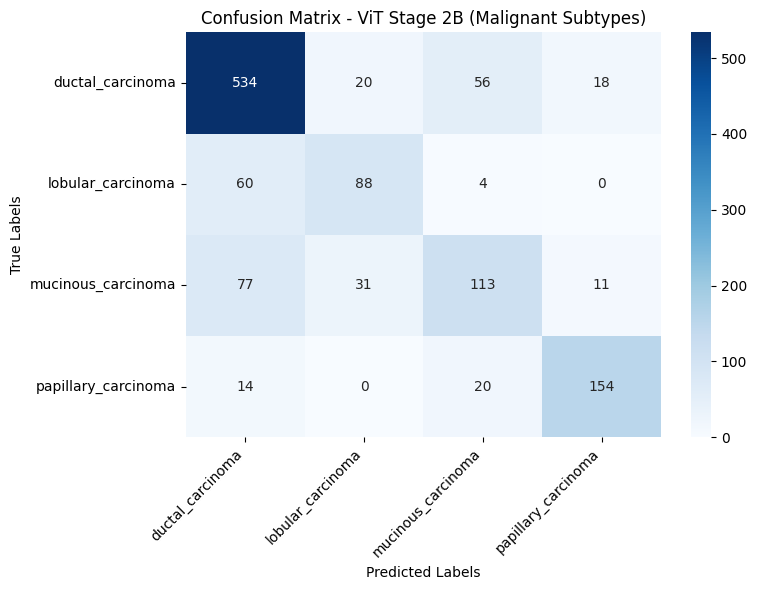

Model saved as 'vit_FocalLoss_Stage2B_Malignant.pth'


In [12]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# TRAINING LOOP (STAGE 2B: MALIGNANT SUBTYPES)
# ==========================================
NUM_EPOCHS = 15
print("Starting training for Stage 2B (Malignant Subtypes) with Focal Loss...\n")

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model_vit_mal.train()
    running_loss, running_corrects, total_train = 0.0, 0, 0

    for inputs, labels in train_loader_mal:
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer_mal.zero_grad()
        outputs = model_vit_mal(inputs)

        loss = criterion_mal(outputs, labels)

        loss.backward()
        optimizer_mal.step()

        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_train += inputs.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = running_corrects.float() / total_train

    # --- VALIDATION (TEST) PHASE ---
    model_vit_mal.eval()
    running_test_loss, running_test_corrects, total_test = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in test_loader_mal:
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            outputs = model_vit_mal(inputs)
            loss = criterion_mal(outputs, labels)

            _, preds = torch.max(outputs, 1)
            running_test_loss += loss.item() * inputs.size(0)
            running_test_corrects += torch.sum(preds == labels.data)
            total_test += inputs.size(0)

            # Store predictions during the final epoch to generate the confusion matrix
            if epoch == NUM_EPOCHS - 1:
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    epoch_test_loss = running_test_loss / total_test
    epoch_test_acc = running_test_corrects.float() / total_test
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} ({epoch_time:.1f}s) -> "
          f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
          f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}")

print("\nStage 2B (Malignant Subtypes) Training finished successfully.")

# ==========================================
# EVALUATION & CONFUSION MATRIX
# ==========================================
print("\nGenerating Detailed Performance Report for Malignant Subtypes...")
class_names_mal = [train_dataset_mal.classes[i] for i in range(num_classes_mal)]

# Generate the classification report
report_mal = classification_report(all_labels, all_preds, target_names=class_names_mal, zero_division=0)
print("-" * 50)
print(report_mal)
print("-" * 50)

# Generate and plot confusion matrix
cm_mal = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_mal, annot=True, fmt='d', cmap='Blues', xticklabels=class_names_mal, yticklabels=class_names_mal)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - ViT Stage 2B (Malignant Subtypes)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save the Malignant subtype classifier model
save_path_mal = "/content/drive/MyDrive/Colab Notebooks/dataset_cancer_v1/multiclass_classification/vit_FocalLoss_Stage2B_Malignant.pth"
torch.save(model_vit_mal.state_dict(), save_path_mal)
print(f"Model saved as 'vit_FocalLoss_Stage2B_Malignant.pth'")